In [ ]:
import pandas as pd

df = pd.read_csv('/content/processed_insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE: 2555.9294270283576
MSE: 21420846.45966618
R² Score: 0.8834278119122363


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        4182.35,
        2593.36,
        mae_rf
    ],
    "MSE": [
        35493102.61,
        19778189.65,
        mse_rf
    ],
    "R2 Score": [
        0.8068,
        0.8924,
        r2_rf
    ]
})

comparison

,Model,MAE,MSE,R2 Score
0,Linear Regression,4182.350000,3.549310e+07,0.806800
1,Decision Tree,2593.360000,1.977819e+07,0.892400
2,Random Forest,2555.929427,2.142085e+07,0.883428


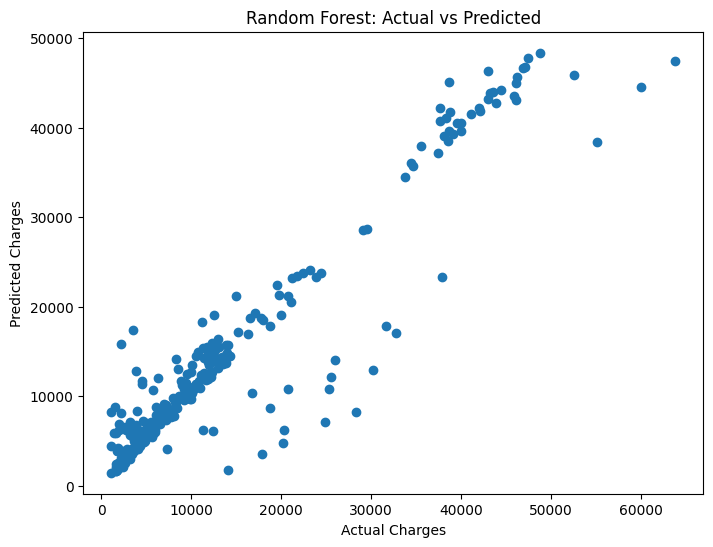

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
4,smoker,0.600777
2,bmi,0.216233
0,age,0.136493
3,children,0.023249
5,region,0.016107
1,sex,0.007141


In [ ]:
import joblib

joblib.dump(
    rf_model,
    'random_forest_model.pkl'
)

['random_forest_model.pkl']